<a href="https://colab.research.google.com/github/Deivi-2000/fundamentos_de_ciencias_de_datos/blob/main/sp_3_david_mejia_casta%C3%B1o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="imgs\banner_fcd.jpg" alt="bannersp" width="1100"  height="150">

# <span style="color:#2F749F;"><strong>📦 Sesión práctica 3: Codificación y transformación de variables</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_3_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

David Mejía Castaño
cc 1007221842

---



## <span style="color:#2F749F;"><strong>Ejercicio 1: Comparación de métodos de escalamiento</strong></span>

A partir de un conjunto de datos real sobre **vinos**, analiza cómo cambia la escala de las variables al aplicar diferentes métodos de **escalamiento de datos**, y compara visualmente sus efectos sobre la distribución.

1. Carga el conjunto de datos **wine** desde la librería `sklearn.datasets` usando `load_wine()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `alcohol`
   - `malic_acid`
   - `color_intensity`

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - `StandardScaler`
   - `MinMaxScaler`
   - `RobustScaler`
   - `Z-Score`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **StandardScaler**
   - Distribución con **MinMaxScaler**
   - Distribución con **RobustScaler**
   - Distribución con **Z-Score**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [ ]:
#librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.datasets import load_wine
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import plotly.graph_objects as go

In [ ]:
# Cargar datos
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Vista general
print("Primeras filas del dataset:")
display(df.head())

# Tamaño, tipos de variables y valores nulos
print("\nInformación general:")
df.info()

print("\nResumen estadístico:")
display(df.describe(include='all'))

print("\nValores nulos por columna:")
display(df.isnull().sum())



Primeras filas del dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000



Valores nulos por columna:


,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


**DESCRIPCIÓN DEL DATASET**

El dataset Wine contiene información química de 178 muestras de vino

**Variables principales:**
- `alcohol`: porcentaje de alcohol presente en el vino
- `malic_acid`: cantidad de ácido málico
- `ash`: contenido de cenizas
- `alcalinity_of_ash`: alcalinidad de las cenizas
- `magnesium`: cantidad de magnesio
- `total_phenols`: contenido total de compuestos fenólicos
- `flavanoids`: cantidad de flavonoides
- `nonflavanoid_phenols`: fenoles no flavonoides
- `proanthocyanins`: compuestos relacionados con el color y sabor
- `color_intensity`: intensidad del color del vino
- `hue`: tonalidad del color
- `od280/od315_of_diluted_wines`: medida de dilución relacionada con proteínas
- `proline`: cantidad de prolina

In [ ]:
# Limpieza de columnas irrelevantes
df.drop(columns=['malic_acid','ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'nonflavanoid_phenols', 'proanthocyanins', 'hue', 'od280/od315_of_diluted_wines', 'proline'], inplace=True)

Para el análisis se tomaron las siguientes variables numéricas:
- `alcohol`
- `flavonoids`
- `color_intensity`

In [ ]:
# Selección de variables
X = df[['alcohol', 'flavanoids', 'color_intensity']]

# Aplicando StandardScaler

scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)

df_std = pd.DataFrame(X_std, columns=X.columns)
df_std.head()

# Aplicando MinMaxScaler

scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

df_minmax = pd.DataFrame(X_minmax, columns=X.columns)
df_minmax.head()

# Aplicando RobustScaler

scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X)

df_robust = pd.DataFrame(X_robust, columns=X.columns)
df_robust.head()

# Aplicando Z-Score

df_zscore = (X - X.mean()) / X.std()
df_zscore.head()

,alcohol,flavanoids,color_intensity
0,1.514341,1.031908,0.251009
1,0.245597,0.731565,-0.292496
2,0.196325,1.212114,0.268263
3,1.686791,1.462399,1.182732
4,0.294868,0.661485,-0.318377


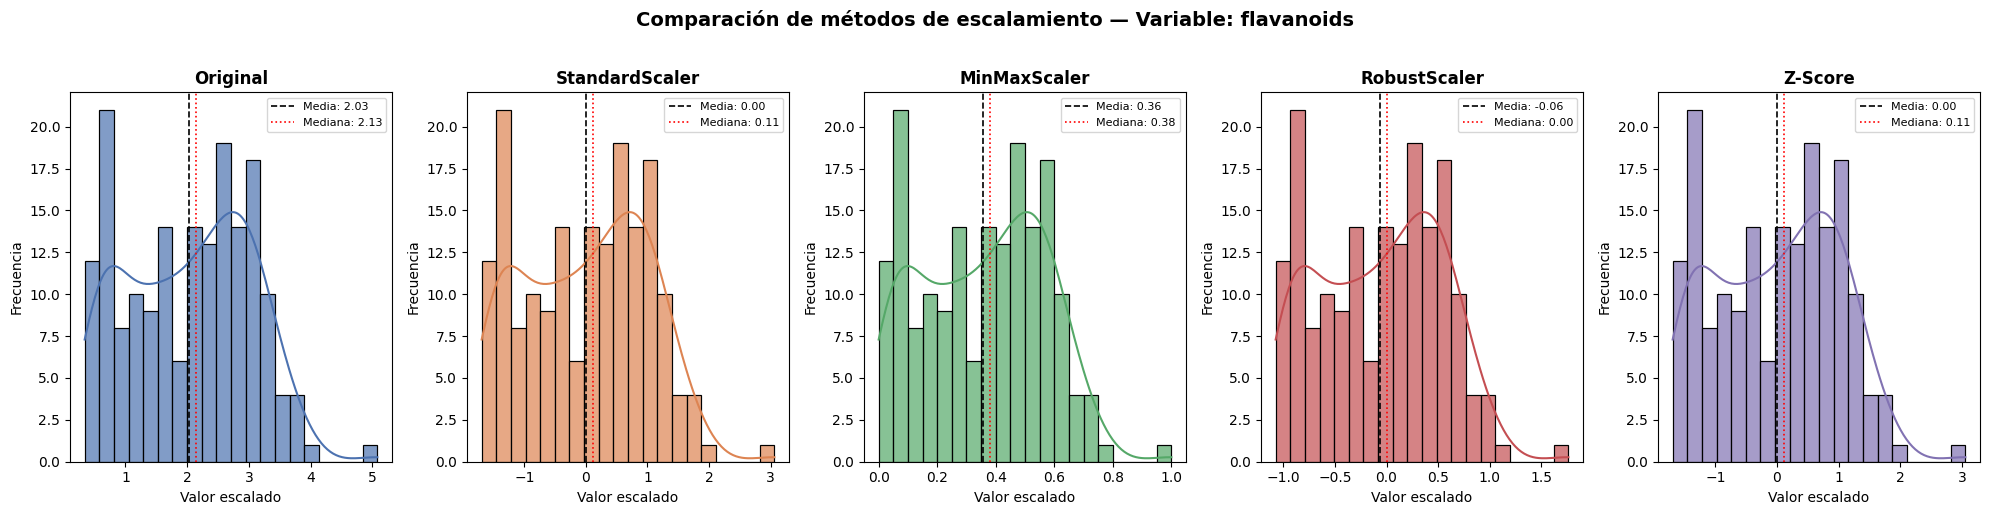

In [ ]:
# Variable a visualizar
var = 'flavanoids'

# Datos de cada método
datos = {
    'Original': X[var],
    'StandardScaler': df_std[var],
    'MinMaxScaler': df_minmax[var],
    'RobustScaler': df_robust[var],
    'Z-Score': df_zscore[var]
}

colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle(f'Comparación de métodos de escalamiento — Variable: {var}',
             fontsize=14, fontweight='bold', y=1.02)

for ax, (nombre, serie), color in zip(axes, datos.items(), colores):
    sns.histplot(serie, kde=True, ax=ax, color=color, bins=20, alpha=0.7)
    ax.set_title(nombre, fontsize=12, fontweight='bold')
    ax.set_xlabel('Valor escalado', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.axvline(serie.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Media: {serie.mean():.2f}')
    ax.axvline(serie.median(), color='red', linestyle=':', linewidth=1.2, label=f'Mediana: {serie.median():.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Conclusión**

Al comparar las cinco gráficas, lo primero que se observa es que la forma de la
distribución no cambia, independientemente del método aplicado es decir, cada método cambia la escala, pero no la forma de los datos: StandardScaler y Z-Score centran en cero con dispersión uniforme, MinMax comprime todo entre 0 y 1, y RobustScaler usa la mediana para resistir valores extremos.



## <span style="color:#2F749F;"><strong>Ejercicio 2: Comparación de escalamiento RobustScaler vs Z-Score</strong></span>

A partir de un conjunto de datos real sobre **diabetes**, analiza cómo cambia la escala de las variables al aplicar **estandarización con Z-Score** y **escalamiento robusto**, y compara visualmente sus efectos cuando existen **posibles valores atípicos**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo: `bmi`, `bp`, `s5` u otras disponibles en el dataset).

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - **StandardScaler** (Z-Score).
   - **RobustScaler** (basado en mediana e IQR).

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución **escalada con Z-Score**
   - Distribución **escalada con RobustScaler**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [ ]:
from sklearn.datasets import load_diabetes

In [ ]:
# Cargar datos
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Vista general
print("Primeras filas del dataset:")
display(df.head())

# Tamaño, tipos de variables y valores nulos
print("\nInformación general:")
df.info()

print("\nResumen estadístico:")
display(df.describe(include='all'))

print("\nValores nulos por columna:")
display(df.isnull().sum())

Primeras filas del dataset:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB

Resumen estadístico:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01



Valores nulos por columna:


,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


**DESCRIPCIÓN DEL DATASET**

El dataset Diabetes contiene información médica de 442 pacientes. Su objetivo es analizar cómo diferentes variables fisiológicas influyen en la progresión de la diabetes a lo largo del tiempo.

**Varibales Principales**

- `age`: edad del paciente
- `sex`: sexo del paciente
- `bmi`: índice de masa corporal
- `bp`: presión arterial
- `s1`: colesterol total
- `s2`: lipoproteínas de baja densidad (LDL)
- `s3`: lipoproteínas de alta densidad (HDL)
- `s4`: relación colesterol total / HDL
- `s5`: nivel de triglicéridos
- `s6`: nivel de glucosa en sangre

In [ ]:
# Limpieza de columnas irrelevantes
df.drop(columns=['sex','s1', 's2', 's3', 's4', 's5', 's6'], inplace=True)

Para el análisis se tomaron las siguientes variables numéricas:

- `age`
- `bmi`
- `bp`

In [ ]:
Y = df[['age', 'bmi', 'bp']]

# Aplicando StandardScaler

scaler_std = StandardScaler()
Y_std = scaler_std.fit_transform(Y)

df_std = pd.DataFrame(Y_std, columns=Y.columns)
df_std.head()

# Aplicando RobustScaler

scaler_robust = RobustScaler()
Y_robust = scaler_robust.fit_transform(Y)

df_robust = pd.DataFrame(Y_robust, columns=Y.columns)
df_robust.head()

,age,bmi,bp
0,0.433735,1.053498,0.380952
1,-0.096386,-0.674897,-0.285714
2,1.060241,0.790123,0.000000
3,-1.253012,-0.065844,-0.428571
4,0.000000,-0.444444,0.380952


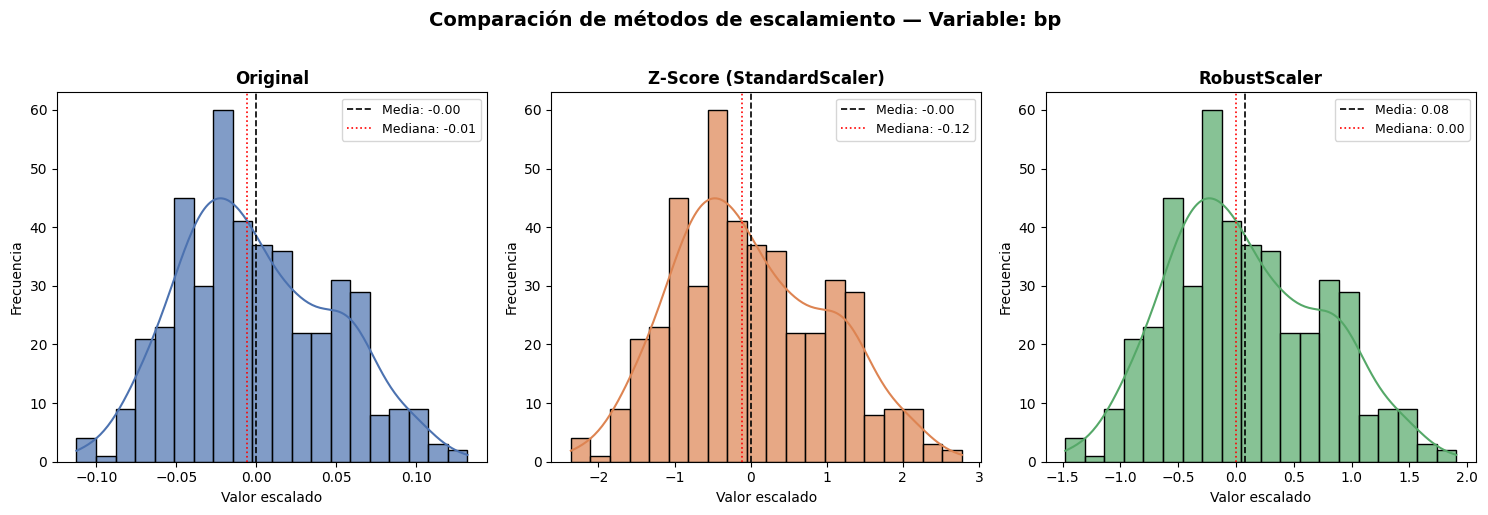

In [ ]:
# Variable a visualizar
var = 'bp'

# Datos de cada escenario
datos = {
    'Original': Y[var],
    'Z-Score (StandardScaler)': df_std[var],
    'RobustScaler': df_robust[var]
}

colores = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Comparación de métodos de escalamiento — Variable: {var}',
             fontsize=14, fontweight='bold', y=1.02)

for ax, (nombre, serie), color in zip(axes, datos.items(), colores):
    sns.histplot(serie, kde=True, ax=ax, color=color, bins=20, alpha=0.7)
    ax.set_title(nombre, fontsize=12, fontweight='bold')
    ax.set_xlabel('Valor escalado', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.axvline(serie.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Media: {serie.mean():.2f}')
    ax.axvline(serie.median(), color='red', linestyle=':', linewidth=1.2,
               label=f'Mediana: {serie.median():.2f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Conclusión**

Al observar las distribuciones de bp, queda claro que tanto el Z-Score como el RobustScaler preservan la forma original de la variable, cambiando únicamente la escala (como se mencionó en la conclusión del Ejercicio 1). Ahora, En un contexto donde puede haber registros extremos, el RobustScaler es la opción más recomendable, ya que garantiza una transformación más representativa y robusta sin que los valores extremos distorsionen el escalamiento del resto de los datos.

## <span style="color:#2F749F;"><strong>Ejercicio 3: Comparación de normalización L1 y L2</strong></span>

A partir de un conjunto de datos real sobre **precios de viviendas**, analiza cómo cambian los valores de las variables al aplicar **normalización L1 y L2**, y compara visualmente sus efectos sobre la distribución de los datos.

1. Carga el conjunto de datos **California Housing** desde la librería `sklearn.datasets` usando `fetch_california_housing()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `MedInc`
   - `AveRooms`
   - `HouseAge`

4. Aplica los siguientes métodos de **normalización** sobre las variables seleccionadas utilizando `Normalizer` de `sklearn.preprocessing`:
   - **Normalización L1**
   - **Normalización L2**

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **normalización L1**
   - Distribución con **normalización L2**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [ ]:
from sklearn.datasets import fetch_california_housing

In [37]:
# Cargar datos
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Vista general
print("Primeras filas del dataset:")
display(df.head())

# Tamaño, tipos de variables y valores nulos
print("\nInformación general:")
df.info()

print("\nResumen estadístico:")
display(df.describe(include='all'))

print("\nValores nulos por columna:")
display(df.isnull().sum())

HTTPError: HTTP Error 403: Forbidden

**DESCRIPCIÓN DEL DATASET**

El dataset `fetch_california_housing()` contiene información sobre características socioeconómicas y geográficas de distintas zonas de California, con el objetivo de predecir el valor medio de las viviendas.

**Varibales Principales**

- `MedInc`: ingreso medio de los habitantes del área
- `HouseAge`: antigüedad promedio de las viviendas
- `AveRooms`: promedio de habitaciones por vivienda
- `AveBedrms`: promedio de dormitorios
- `Population`: población del área
- `AveOccup`: promedio de ocupantes por vivienda
- `Latitude`: latitud geográfica
- `Longitude`: longitud geográfica

In [ ]:
# Limpieza de columnas irrelevantes
df.drop(columns=['HouseAge','AveBedrms', 'AveOccup', 'Latitude', 'Longitude'], inplace=True)

Para el análisis se tomaron las siguientes variables numéricas:

- `MedInc`
- `AveRooms`
- `Population`

In [ ]:
from sklearn.preprocessing import Normalizer

In [ ]:
Z = df [['MedInc', 'AveRooms', 'Population']]

normalizer_l1 = Normalizer(norm='l1')
Z_l1 = normalizer_l1.fit_transform(Z)

df_l1 = pd.DataFrame(Z_l1, columns=Z.columns)
df_l1.head()

normalizer_l2 = Normalizer(norm='l2')
Z_l2 = normalizer_l2.fit_transform(Z)

df_l2 = pd.DataFrame(Z_l2, columns=Z.columns)
df_l2.head()

,MedInc,AveRooms,Population
0,0.025840,0.021677,0.999431
1,0.003457,0.002598,0.999991
2,0.014628,0.016706,0.999753
3,0.010112,0.010424,0.999895
4,0.006807,0.011117,0.999915


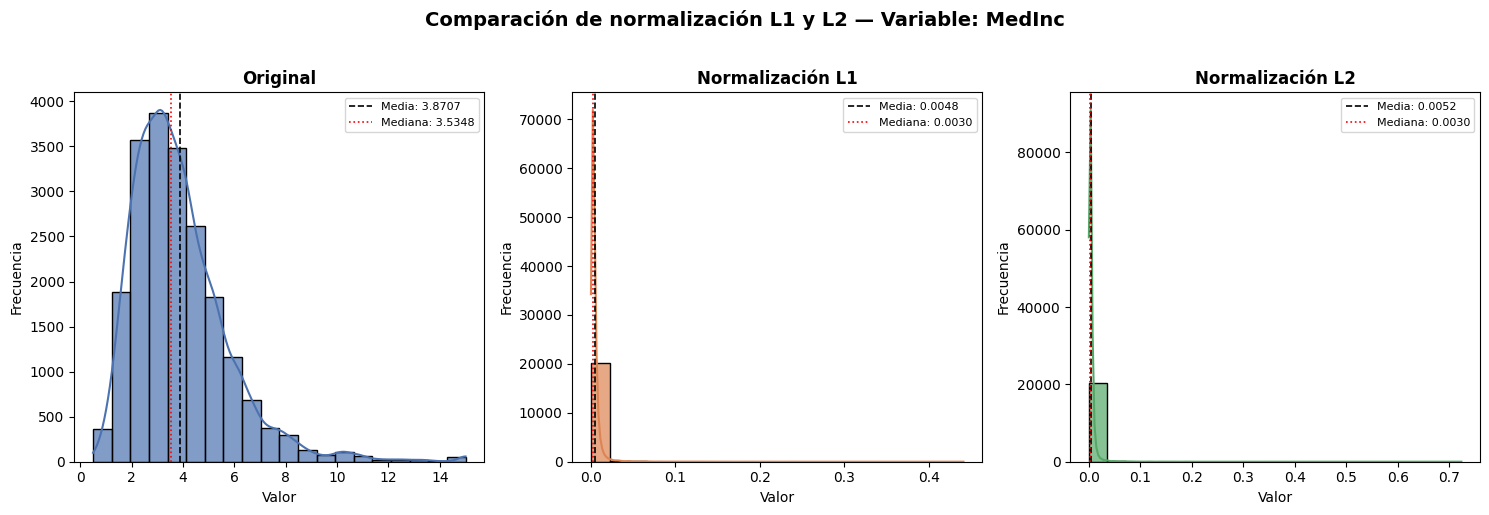

In [ ]:
# Variable a visualizar
var = 'MedInc'

# Datos de cada escenario
datos = {
    'Original': Z[var],
    'Normalización L1': df_l1[var],
    'Normalización L2': df_l2[var]
}

colores = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Comparación de normalización L1 y L2 — Variable: {var}',
             fontsize=14, fontweight='bold', y=1.02)

for ax, (nombre, serie), color in zip(axes, datos.items(), colores):
    sns.histplot(serie, kde=True, ax=ax, color=color, bins=20, alpha=0.7)
    ax.set_title(nombre, fontsize=12, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.axvline(serie.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Media: {serie.mean():.4f}')
    ax.axvline(serie.median(), color='red', linestyle=':', linewidth=1.2,
               label=f'Mediana: {serie.median():.4f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Conclusión**

En la gráfica original vemos que hay una forma sesgada hacia la izquierda. Luego de aplicar la normalización $L_1$ y $L_2$ los valores se comprimen hacia un rango cercano a $0$.

## <span style="color:#2F749F;"><strong>Ejercicio 4: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con diabetes**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo: `bmi`, `bp` o `s5`).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Transformación logarítmica** usando `np.log()` o `np.log1p()`
   - **Transformación logarítmica reflejada** (útil cuando existe asimetría negativa)
   - **Transformación cuadrática** usando `x²`
   - **Transformación Box-Cox** usando `scipy.stats.boxcox`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación log**
   - Distribución con **log reflejado**
   - Distribución con **transformación cuadrática**
   - Distribución con **transformación Box-Cox**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [38]:
# Cargar datos
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# Vista general
print("Primeras filas del dataset:")
display(df.head())

# Tamaño, tipos de variables y valores nulos
print("\nInformación general:")
df.info()

print("\nResumen estadístico:")
display(df.describe(include='all'))

print("\nValores nulos por columna:")
display(df.isnull().sum())

Primeras filas del dataset:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB

Resumen estadístico:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01



Valores nulos por columna:


,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


In [42]:
from scipy.stats import boxcox

# Variable a transformar
var = 'bmi'
W= df[var]

#Transformación logarítmica
bmi_log = np.log1p(W)

#Transformación logarítmica reflejada
bmi_log_ref = np.log1p(W.max() + 1 - W)

#Transformación cuadrática
bmi_cuad = W ** 2

#Transformación Box-Cox
bmi_boxcox, lambda_optimo = boxcox(W + 1)
bmi_boxcox = pd.Series(bmi_boxcox, name=var)



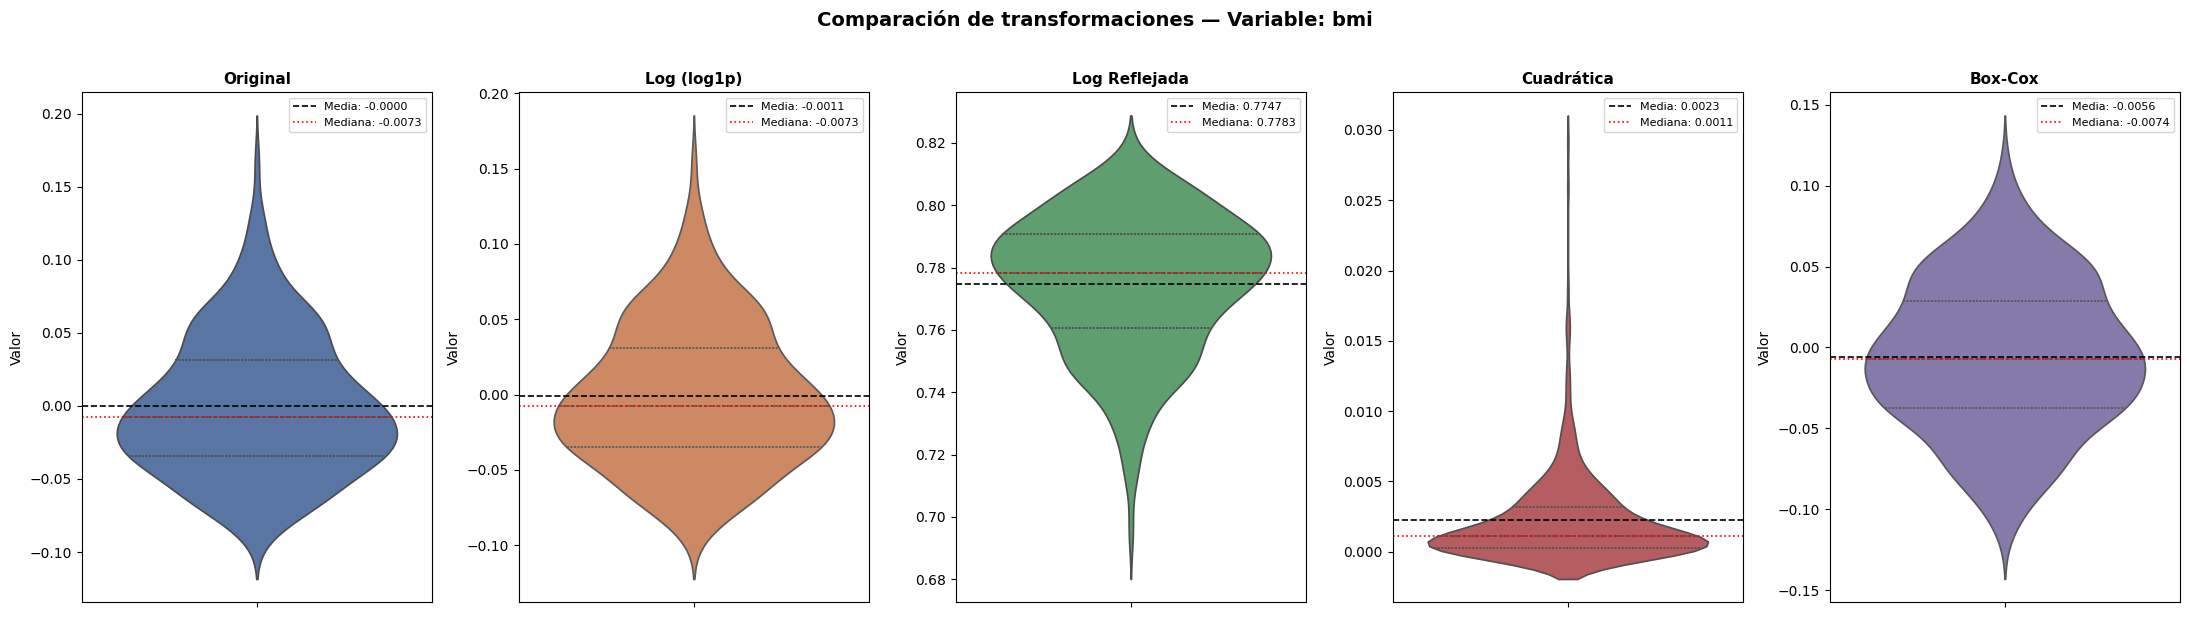

In [40]:
# Construir DataFrame con todas las transformaciones
df_transforms = pd.DataFrame({
    'Original': serie,
    'Log (log1p)': bmi_log,
    'Log Reflejada': bmi_log_ref,
    'Cuadrática': bmi_cuad,
    'Box-Cox': bmi_boxcox
})

df_melted = df_transforms.melt(var_name='Transformación', value_name='Valor')

# Colores
colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
palette = dict(zip(['Original', 'Log (log1p)', 'Log Reflejada', 'Cuadrática', 'Box-Cox'], colores))

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle(f'Comparación de transformaciones — Variable: {var}',
             fontsize=14, fontweight='bold', y=1.02)

for ax, (nombre, serie_t), color in zip(axes, df_transforms.items(), colores):
    sns.violinplot(data=serie_t, ax=ax, color=color, inner='quartile')
    ax.set_title(nombre, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Valor', fontsize=10)
    ax.axhline(serie_t.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Media: {serie_t.mean():.4f}')
    ax.axhline(serie_t.median(), color='red', linestyle=':', linewidth=1.2,
               label=f'Mediana: {serie_t.median():.4f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Conclusión**

